# Oil Factor Signal Research
(By Victor)

**Brief:** Given ten years of daily data on a proprietary factor ("Factor A") and crude oil, identify the best way to use the factor to trade oil with long / short / neutral positions.

## 1. Data

2,521 daily observations, July 2016 to July 2026. Five columns: date, Factor A level, factor daily return, crude oil price, oil daily return.

Before any analysis: load, sort, verify integrity, and screen for anomalies that would corrupt return calculations.

In [1]:
!pip install pandas numpy matplotlib scipy scikit-learn statsmodels hmmlearn openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

df = pd.read_excel('20260705 oil price factor.xlsx')

df = df.rename(columns={
    'factor A':       'factor',
    'daily return':   'factor_ret',
    'oil price':      'oil',
    'daily return.1': 'oil_ret'
})

# File arrives newest-first. Sort ascending — rolling windows and forward
# shifts on a reverse-sorted frame would silently read the future.
df = df.sort_values('Date').reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print()
print(df.head(3).to_string())
print()
print(df.tail(3).to_string())


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Rows: 2521
Range: 2016-07-05 to 2026-07-03

        Date      factor  factor_ret    oil   oil_ret
0 2016-07-05  100.000000         NaN  46.60       NaN
1 2016-07-06   99.939644   -0.000604  47.43  0.017811
2 2016-07-07  100.080475    0.001409  45.14 -0.048282

           Date      factor  factor_ret    oil   oil_ret
2518 2026-07-01  827.542501   -0.000510  68.58 -0.013237
2519 2026-07-02  818.398551   -0.011050  68.69  0.001604
2520 2026-07-03  823.850719    0.006662  68.78  0.001310


### 1.2 Integrity checks

Three checks before trusting the data: no duplicate dates, missing values only where expected, and the supplied return columns consistent with the price series.

In [2]:
# 1. Duplicate dates
print("Duplicate dates:", df['Date'].duplicated().sum())

# 2. Missing values
print("\nMissing values:")
print(df.isnull().sum().to_dict())
print("\nRows with NaN:")
print(df[df.isnull().any(axis=1)].to_string(index=False))

# 3. Reconcile the supplied return columns against the price series.
#    pct_change() divides by the previous price. Where that price is negative,
#    the sign flips and the result is meaningless. The sign-correct form
#    divides by |P_prev|, which stays well-defined across a zero crossing.
df['oil_ret_recomputed'] = df['oil'].diff() / df['oil'].shift().abs()
df['factor_ret_recomputed'] = df['factor'].pct_change()

print("\nReconciliation with supplied columns:")
for mine, vendor, label in [('factor_ret_recomputed', 'factor_ret', 'factor'),
                            ('oil_ret_recomputed',    'oil_ret',    'oil')]:
    diff = (df[mine] - df[vendor]).abs()
    bad = df[diff > 1e-6]
    print(f"  {label:8s}: {len(bad)} disagreement(s), max deviation {diff.max():.2e}")
    if len(bad):
        print(bad[['Date', 'oil', vendor, mine]].to_string(index=False))

Duplicate dates: 0

Missing values:
{'Date': 0, 'factor': 0, 'factor_ret': 1, 'oil': 0, 'oil_ret': 1}

Rows with NaN:
      Date  factor  factor_ret  oil  oil_ret
2016-07-05   100.0         NaN 46.6      NaN

Reconciliation with supplied columns:
  factor  : 0 disagreement(s), max deviation 1.11e-16
  oil     : 1 disagreement(s), max deviation 2.53e+00
      Date   oil   oil_ret  oil_ret_recomputed
2020-04-21 10.01 -1.266011            1.266011


### 1.3 Anomaly screening

Percentage returns are undefined across a zero crossing. The price series is screened explicitly for non-positive values before use.

In [3]:
# Screen for non-positive prices, which break percentage-return arithmetic
non_positive = df[df['oil'] <= 0]
print(f"Observations with non-positive oil price: {len(non_positive)}")
print(non_positive[['Date', 'oil']].to_string())

# Inspect the most extreme oil returns
print("\nLargest absolute daily oil returns:")
extreme = df.reindex(df['oil_ret'].abs().sort_values(ascending=False).index)
print(extreme[['Date', 'oil', 'oil_ret']].head(6).to_string())

Observations with non-positive oil price: 1
          Date    oil
955 2020-04-20 -37.63

Largest absolute daily oil returns:
          Date    oil   oil_ret
955 2020-04-20 -37.63 -3.059661
956 2020-04-21  10.01 -1.266011
957 2020-04-22  13.78  0.376623
963 2020-04-30  18.84  0.250996
944 2020-04-02  25.32  0.246677
926 2020-03-09  31.13 -0.245882


**Finding.** On 20 April 2020, WTI crude settled at **−$37.63** — the first negative print in the contract's history, caused by a collapse in storage capacity at Cushing as the May contract approached expiry.

This breaks percentage-return arithmetic. The return *into* that day computes as −306%; the return *out* of it (back to +$10.01) computes as −127%, despite the price having **risen**. Neither figure represents a tradable outcome; both are artefacts of dividing by a price that crosses zero.

Left in place, a short position held across these two days would register a spurious gain of over 400% — dominating the entire backtest with arithmetic rather than signal.

The supplied `oil_ret` column reproduces the −126.6% figure, so the vendor data carries the same defect.

### 1.4 Treatment

The negative-price observation and the day following are excluded, and returns recomputed on the cleaned series.

This is a correction for **undefined arithmetic**, not outlier removal. All other extreme moves — including the ±25% COVID-period days — are retained in full. Note the direction of the correction: it removes a large *fictitious gain*, making the strategy look worse, not better.

In [4]:
# Exclude the negative-price observation and the day following, whose returns
# are both undefined as percentage changes across the zero crossing.
excluded = pd.to_datetime(['2020-04-20', '2020-04-21'])
df_clean = df[~df['Date'].isin(excluded)].copy().reset_index(drop=True)

# Recompute returns on the cleaned price series
df_clean['oil_ret']    = df_clean['oil'].pct_change()
df_clean['factor_ret'] = df_clean['factor'].pct_change()

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
print()
print(f"Max daily oil return: {df_clean['oil_ret'].max():+.2%}")
print(f"Min daily oil return: {df_clean['oil_ret'].min():+.2%}")
print(f"Any non-positive prices remaining: {(df_clean['oil'] <= 0).sum()}")

Rows before cleaning: 2521
Rows after cleaning:  2519

Max daily oil return: +25.10%
Min daily oil return: -24.59%
Any non-positive prices remaining: 0


### 1.5 The series


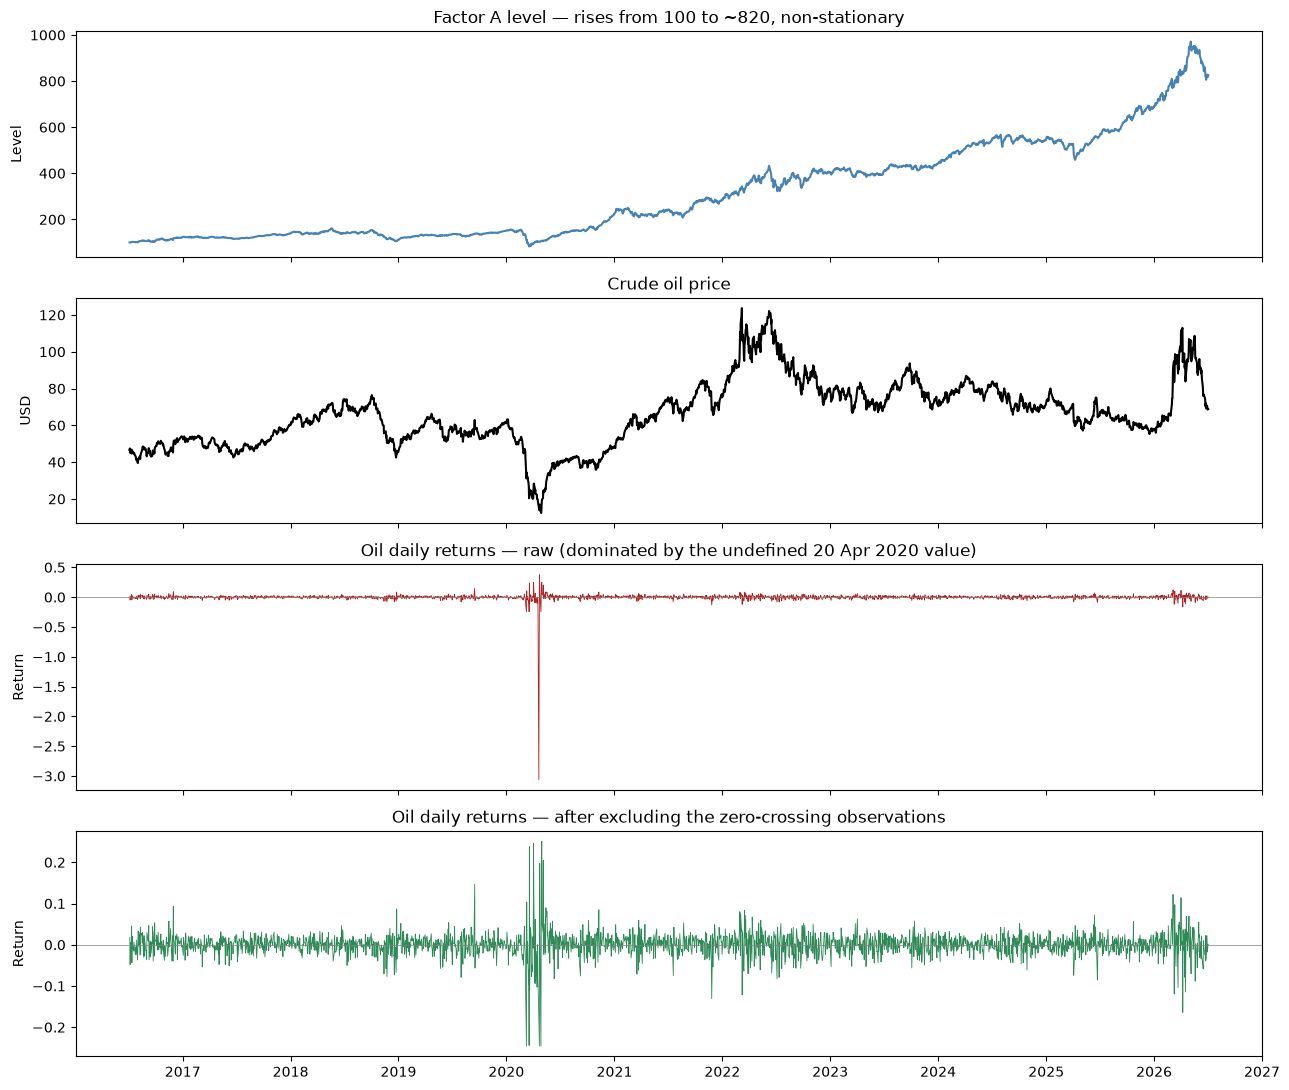

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

# Factor level (cleaned) — shows the non-stationarity
axes[0].plot(df_clean['Date'], df_clean['factor'], color='steelblue')
axes[0].set_title('Factor A level — rises from 100 to ~820, non-stationary')
axes[0].set_ylabel('Level')

# Oil price (cleaned)
axes[1].plot(df_clean['Date'], df_clean['oil'], color='black')
axes[1].set_title('Crude oil price')
axes[1].set_ylabel('USD')

# Oil returns — BEFORE
axes[2].plot(df['Date'], df['oil_ret'], color='firebrick', lw=0.6)
axes[2].set_title('Oil daily returns — raw (dominated by the undefined 20 Apr 2020 value)')
axes[2].set_ylabel('Return')
axes[2].axhline(0, color='grey', lw=0.5)

# Oil returns — AFTER
axes[3].plot(df_clean['Date'], df_clean['oil_ret'], color='seagreen', lw=0.6)
axes[3].set_title('Oil daily returns — after excluding the zero-crossing observations')
axes[3].set_ylabel('Return')
axes[3].axhline(0, color='grey', lw=0.5)

plt.tight_layout()
plt.show()

**Factor A is non-stationary.** It rises from a base of 100 in 2016 to roughly 820 by 2026, so its absolute level carries no consistent meaning: a reading of 400 is historically high in 2019 and low in 2025.

Any signal must therefore be built from a **standardised or differenced** transformation of the factor, never its raw level. This constraint shapes the entire signal design in Section 3.

## Section 2: Factor Analysis

Before designing any trading rule, the question is whether Factor A carries predictive information about oil at all. A factor can be represented in several ways, and each representation embodies a different economic hypothesis. Two are tested here.

The information coefficient (IC) is the rank correlation between a factor representation and forward oil returns. Spearman rank correlation is used rather than Pearson, since financial returns are fat-tailed and rank correlation is robust to outliers without assuming a linear relationship. A statistically significant, non-zero IC indicates genuine predictive content; an IC indistinguishable from zero means no signal construction, however sophisticated, could extract value from that representation.

### 2.1 Momentum hypothesis

Does factor *movement* predict oil? The factor's daily return is tested against forward oil returns at 1, 5, and 20 trading days.

Multiple horizons identify not just whether the factor predicts, but how fast its information decays — which sets the natural trading frequency.

In [6]:
from scipy import stats

d = df_clean.copy()

# Forward oil returns over 1, 5, and 20 trading days
d['oil_fwd_1']  = d['oil'].pct_change(1).shift(-1)
d['oil_fwd_5']  = d['oil'].pct_change(5).shift(-5)
d['oil_fwd_20'] = d['oil'].pct_change(20).shift(-20)

def rank_ic(signal_col, fwd_col, data):
    """Spearman rank IC between a signal and forward returns."""
    valid = data[[signal_col, fwd_col]].dropna()
    ic, p = stats.spearmanr(valid[signal_col], valid[fwd_col])
    return ic, p, len(valid)

print("Momentum hypothesis — IC of factor daily return vs forward oil returns\n")
print(f"{'Horizon':<12}{'Rank IC':>10}{'p-value':>10}{'n':>8}  Significant")
print("-" * 52)
for h, label in [('oil_fwd_1', '1 day'), ('oil_fwd_5', '5 days'), ('oil_fwd_20', '20 days')]:
    ic, p, n = rank_ic('factor_ret', h, d)
    sig = "Yes" if p < 0.05 else "No"
    print(f"{label:<12}{ic:>+10.4f}{p:>10.4f}{n:>8}  {sig}")

# IC magnitude: ~0.02–0.05 is weak, ~0.05–0.10 is real and useful, 
# >0.10 for a single factor is strong.
# IC = 0, Factor A tells nth abt futuure oil, useless

# p-value: below 0.05 means statistically significant.

Momentum hypothesis — IC of factor daily return vs forward oil returns

Horizon        Rank IC   p-value       n  Significant
----------------------------------------------------
1 day          +0.0452    0.0233    2517  Yes
5 days         +0.0648    0.0011    2513  Yes
20 days        +0.0268    0.1802    2498  No


### Pearson (magnitude-sensitive) vs Spearman (rank-based)

In [7]:
# Pearson (magnitude-sensitive) vs Spearman (rank-based), before and after cleaning
raw = df.copy()
raw['oil_fwd_5'] = raw['oil'].pct_change(5).shift(-5)
v_raw = raw[['factor_ret','oil_fwd_5']].dropna()

v_clean = d[['factor_ret','oil_fwd_5']].dropna()

print("                    Raw data      Cleaned data")
print(f"Pearson  IC:      {stats.pearsonr(v_raw['factor_ret'], v_raw['oil_fwd_5'])[0]:+.4f}       {stats.pearsonr(v_clean['factor_ret'], v_clean['oil_fwd_5'])[0]:+.4f}")
print(f"Spearman IC:      {stats.spearmanr(v_raw['factor_ret'], v_raw['oil_fwd_5'])[0]:+.4f}       {stats.spearmanr(v_clean['factor_ret'], v_clean['oil_fwd_5'])[0]:+.4f}")

                    Raw data      Cleaned data
Pearson  IC:      +0.0460       +0.0496
Spearman IC:      +0.0654       +0.0648


The rank IC is essentially unchanged by the data cleaning, since Spearman correlation depends only on ordering and is therefore insensitive to the magnitude of the undefined observation. The Pearson IC, by contrast, shifts materially. This illustrates why rank IC is preferred for factor evaluation — though the cleaning remains essential for the backtest, where returns enter the P&L by magnitude rather than by rank.

**Findings.**

| Horizon | Rank IC | p-value | Significant |
|---|---|---|---|
| 1 day | +0.045 | 0.023 | Yes |
| **5 days** | **+0.065** | **0.001** | **Yes** |
| 20 days | +0.027 | 0.180 | No |

Three implications for design:

1. **The factor predicts, not merely co-moves.** The correlation is against *forward* returns.
2. **Information decays fast** — concentrated in a week, gone within a month. The 5-day peak sets the rebalancing frequency.
3. **The sign is positive** — trade directionally with the factor.

Magnitude (IC ≈ 0.065) is modest but normal for a single factor; institutional single-factor ICs typically fall in 0.02–0.10. Calibrating from this, a realistic expectation for the resulting strategy is a Sharpe of roughly 0.5–0.9, not materially higher.

### 2.2 Extremeness hypothesis

Does the factor *level* predict oil? A different claim: that the factor being unusually high or low relative to its recent range forecasts oil — a mean-reversion effect rather than momentum.

The raw level cannot be used (non-stationary), so it is standardised into a rolling 60-day z-score and the same IC test applied.

In [9]:
window = 60

# Rolling z-score of the factor level
roll_mean = d['factor'].rolling(window).mean()
roll_std  = d['factor'].rolling(window).std()
d['z_level'] = (d['factor'] - roll_mean) / roll_std

print("Extremeness hypothesis — IC of z-scored factor level vs forward oil returns\n")
print(f"{'Horizon':<12}{'Rank IC':>10}{'p-value':>10}{'n':>8}  Significant")
print("-" * 52)
for h, label in [('oil_fwd_1', '1 day'), ('oil_fwd_5', '5 days'), ('oil_fwd_20', '20 days')]:
    ic, p, n = rank_ic('z_level', h, d)
    sig = "Yes" if p < 0.05 else "No"
    print(f"{label:<12}{ic:>+10.4f}{p:>10.4f}{n:>8}  {sig}")

# How much time does the z-scored level spend positive?
# A trending series sits above its own rolling mean most of the time,
# which would embed a structural directional bias into any level-based signal.
pct_positive = (d['z_level'] > 0).mean()
print(f"\nProportion of days with z_level > 0: {pct_positive:.1%}")

Extremeness hypothesis — IC of z-scored factor level vs forward oil returns

Horizon        Rank IC   p-value       n  Significant
----------------------------------------------------
1 day          +0.0329    0.1030    2459  No
5 days         +0.0628    0.0019    2455  Yes
20 days        +0.0373    0.0655    2440  No

Proportion of days with z_level > 0: 67.3%


**A problem.** The z-scored level sits above zero on **67.3%** of days — not ~50% as an unbiased extremeness measure should.

This is mechanical: a trending series is almost always above its own trailing mean. So a long/short rule built on this signal would be long roughly twice as often as short **by construction, not by prediction**. Since oil rose over the sample, its apparent IC cannot be distinguished from simply being persistently long a rising asset.

The significance in 2.2 is therefore suspect and must be tested further.

### 2.3 Are the two signals independent?

Both representations show a similar 5-day IC (+0.065 momentum, +0.063 level), raising the possibility they detect the same effect — a rising factor mechanically pushes its z-score up.

To test this, the level is regressed on momentum and the **residual** — the part momentum cannot explain — is tested for predictive power.


In [10]:
# Are the two signals just proxies for each other?
both = d[['factor_ret', 'z_level', 'oil_fwd_5']].dropna()
corr = stats.spearmanr(both['factor_ret'], both['z_level'])[0]
print(f"Correlation between factor_ret and z_level: {corr:+.4f}")

# Does z_level predict oil AFTER removing what momentum already explains?
from scipy.stats import rankdata
import statsmodels.api as sm

# Rank-transform everything (keeps it consistent with rank IC)
r_mom  = rankdata(both['factor_ret'])
r_lvl  = rankdata(both['z_level'])
r_fwd  = rankdata(both['oil_fwd_5'])

# Regress the level on momentum, keep only the part momentum can't explain
resid_lvl = sm.OLS(r_lvl, sm.add_constant(r_mom)).fit().resid

ic_resid, p_resid = stats.spearmanr(resid_lvl, r_fwd)
print(f"IC of level, after removing momentum: {ic_resid:+.4f}, p = {p_resid:.4f}")

Correlation between factor_ret and z_level: +0.2581
IC of level, after removing momentum: +0.0475, p = 0.0185


**Result.** The two signals are only moderately correlated (ρ = +0.26). After controlling for momentum, the level retains significant predictive power (residual IC = +0.048, p = 0.019).

So the level is **not** a momentum proxy — it carries independent information. That makes the directional bias problem more pressing, not less: there is something there, but it may be beta rather than signal.

## 2.4: Debiasing the level signal (use percentile)

The z-scored level in 2.2 sits above zero on 67.3% of days. This is a mechanical consequence of z-scoring a trending series: a rising factor is almost always above its own trailing mean. Any long/short rule built on this signal would therefore be long roughly twice as often as short, by construction rather than by prediction — embedding an unintended directional exposure to oil.

This raises a serious question about the 2.2 result: is the observed IC genuine predictive power, or simply the reward for being persistently long an asset that rose over the sample?

To separate the two, the level is reconstructed as a rolling percentile rank, comparing the factor to the full distribution of its trailing 252 days rather than to a single mean. A percentile rank is balanced by construction — a trend cannot push it permanently to one side — so any predictive power that survives is attributable to the signal rather than to directional drift.

In [11]:
lookback = 252  # one year

# Percentile rank of today's factor within its trailing distribution
d['level_rank'] = d['factor'].rolling(lookback).apply(
    lambda x: (x[-1] > x[:-1]).mean(), raw=True
)

# Centre at zero: ranges -0.5 (lowest in a year) to +0.5 (highest in a year)
d['level_signal'] = d['level_rank'] - 0.5

# --- Confirm the bias is removed ---
print("Directional balance")
print("-" * 45)
print(f"z-scored level    > 0:  {(d['z_level'] > 0).mean():.1%}   (biased)")
print(f"percentile signal > 0:  {(d['level_signal'] > 0).mean():.1%}   (target ~50%)")
print(f"factor momentum   > 0:  {(d['factor_ret'] > 0).mean():.1%}   (naturally centred)")

# --- Does the signal survive debiasing? ---
print("\nDebiased level signal vs forward oil returns")
print("-" * 55)
print(f"{'Horizon':<12}{'Rank IC':>10}{'p-value':>10}{'n':>8}  Significant")
print("-" * 55)
for h, label in [('oil_fwd_1', '1 day'), ('oil_fwd_5', '5 days'), ('oil_fwd_20', '20 days')]:
    ic, p, n = rank_ic('level_signal', h, d)
    sig = "Yes" if p < 0.05 else "No"
    print(f"{label:<12}{ic:>+10.4f}{p:>10.4f}{n:>8}  {sig}")

Directional balance
---------------------------------------------
z-scored level    > 0:  67.3%   (biased)
percentile signal > 0:  73.5%   (target ~50%)
factor momentum   > 0:  56.3%   (naturally centred)

Debiased level signal vs forward oil returns
-------------------------------------------------------
Horizon        Rank IC   p-value       n  Significant
-------------------------------------------------------
1 day          +0.0129    0.5400    2267  No
5 days         +0.0277    0.1874    2263  No
20 days        +0.0120    0.5682    2248  No


Reconstructing the level as a percentile rank did not remove the directional bias (73.5% positive, versus 67.3% for the z-score), since a strongly trending series sits near the top of its trailing distribution by definition. The correction therefore failed on its own terms.

The test remains informative, however: under this alternative construction the level's 5-day IC falls from +0.063 (p = 0.002) to +0.028 (p = 0.187), losing significance entirely. A genuine edge should not be so sensitive to the choice of transformation. Taken together with the persistent long bias under both constructions, this indicates that the level's apparent predictive power reflects exposure to oil's upward drift rather than forecasting content, and the signal is rejected.

## 2.5 Real Conclusion

Factor momentum is the only representation that survives scrutiny. The level's apparent predictive power is not robust to how the signal is constructed, and its persistent directional bias suggests it reflects exposure to oil's drift rather than genuine forecasting content. Section 3 therefore builds the strategy on factor momentum alone.

## Section 3: Signal Design

Section 2 established one validated signal: factor momentum, with a rank IC of +0.065 against 5-day forward oil returns (p = 0.001), naturally centred (positive on 56.3% of days), and free of the structural directional bias that disqualified the level.
This section converts that signal into tradable long / short / neutral positions. Three decisions are required: how to normalise the raw signal so a fixed threshold means the same thing across time, where to set the entry thresholds, and how large each position should be.

## 3.1 Normaliseing the signal

The IC peaked at the 5-day horizon, so the raw signal is the factor's 5-day return. Its magnitude, however, varies with market conditions: a 2% move is large in a calm period and unremarkable in a volatile one. A fixed cutoff would therefore trade too often in volatile periods and too rarely in quiet ones.
The signal is standardised with a rolling z-score, so that "unusually strong momentum" is judged relative to recent conditions rather than against a fixed level. Note this applies the z-score to a stationary quantity (returns), unlike Section 2.2 where it was applied to a trending level — which is precisely why it is appropriate here and was not there.

In [12]:
sig = df_clean.copy()

mom_window = 5    # horizon where IC peaked
z_window   = 60   # standardisation lookback

# Raw signal: factor's 5-day return
sig['factor_mom'] = sig['factor'].pct_change(mom_window)

# Standardise against its own recent distribution
roll_mean = sig['factor_mom'].rolling(z_window).mean()
roll_std  = sig['factor_mom'].rolling(z_window).std()
sig['signal_z'] = (sig['factor_mom'] - roll_mean) / roll_std

# Confirm the signal is balanced (no structural bias)
print(f"Signal > 0 on {(sig['signal_z'] > 0).mean():.1%} of days   (target ~50%)")
print(f"\nSignal distribution:")
print(sig['signal_z'].describe())

Signal > 0 on 51.2% of days   (target ~50%)

Signal distribution:
count    2455.000000
mean       -0.034770
std         1.092648
min        -4.418338
25%        -0.723557
50%         0.075407
75%         0.702407
max         3.203717
Name: signal_z, dtype: float64


## 3.2: Position sizing: volatility targeting

A signal indicates direction. It does not indicate size. Taking a full notional position in oil regardless of market conditions is not how systematic strategies are run: oil's realised volatility ranged from roughly 20% in calm periods to over 100% during the 2020 collapse, so a constant notional position would deliver wildly inconsistent risk.
Positions are therefore scaled to target a constant 10% annualised volatility. When oil is volatile, position size shrinks; when calm, it expands. Leverage is capped at 2× to prevent excessive sizing during unusually quiet periods.
This has an important secondary effect: during the March–April 2020 dislocation, when oil's volatility spiked, the strategy would have automatically reduced exposure to near zero — precisely when a fixed-notional strategy would have suffered its largest losses.

In [13]:
target_vol = 0.10   # 10% annualised
vol_window = 60
max_leverage = 2.0

# Oil's trailing realised volatility, annualised
sig['oil_vol'] = sig['oil_ret'].rolling(vol_window).std() * np.sqrt(252)

# Scale positions to hit the volatility target
sig['vol_scalar'] = (target_vol / sig['oil_vol']).clip(upper=max_leverage)

print("Volatility scalar distribution:")
print(sig['vol_scalar'].describe())

# Show the effect during the COVID period
covid = sig[(sig['Date'] >= '2020-03-01') & (sig['Date'] <= '2020-05-01')]
print(f"\nMean position scalar, Mar-Apr 2020: {covid['vol_scalar'].mean():.2f}")
print(f"Mean position scalar, full sample:   {sig['vol_scalar'].mean():.2f}")

Volatility scalar distribution:
count    2459.000000
mean        0.305198
std         0.096604
min         0.057051
25%         0.246763
50%         0.296032
75%         0.380730
max         0.542748
Name: vol_scalar, dtype: float64

Mean position scalar, Mar-Apr 2020: 0.13
Mean position scalar, full sample:   0.31


The volatility scalar averages 0.31, implying oil's realised volatility averaged roughly 33% annualised over the sample — so achieving a 10% risk target requires holding about a third of a notional position. The scalar never reached the 2× leverage cap, which is therefore not binding and does not drive results.
The mechanism is most visible during the March–April 2020 dislocation, when the mean scalar fell to 0.13, less than half its full-sample average. As oil's realised volatility spiked, the strategy automatically reduced exposure to near-negligible levels — precisely when a fixed-notional strategy would have suffered its largest losses. This risk reduction is mechanical rather than predictive: it requires no forecast of the crash, only a response to observed volatility.

The scalar never reached the 2× leverage cap (maximum observed: 0.54), so the cap is not binding and does not influence results. It is retained as a control against anomalously low realised volatility.

## 3.3 The strategy function

The complete strategy combines the normalised signal, a threshold rule for direction, and volatility-based sizing. Positions are entered on the day following signal generation, so that no trade uses information unavailable at the time of the decision. Transaction costs of 5 basis points are charged whenever the position changes.

In [14]:
def run_strategy(data, threshold=0.5, mom_window=5, z_window=60,
                 target_vol=0.10, max_leverage=2.0, cost_bps=5.0):
    """
    Momentum-based long/short/neutral oil strategy with volatility targeting.
    Returns a dict of performance metrics and the position series.
    """
    s = data.copy()

    # --- Signal --- (Standardized momentum signal)
    s['factor_mom'] = s['factor'].pct_change(mom_window)      # 5-day factor momentum
    rm = s['factor_mom'].rolling(z_window).mean()
    rs = s['factor_mom'].rolling(z_window).std()
    s['signal_z'] = (s['factor_mom'] - rm) / rs               # standardise it

    # --- Direction ---
    s['direction'] = 0
    s.loc[s['signal_z'] >  threshold, 'direction'] =  1       # long
    s.loc[s['signal_z'] < -threshold, 'direction'] = -1       # short  , else stay neutral

    # --- Size ---
    s['oil_vol']    = s['oil_ret'].rolling(z_window).std() * np.sqrt(252)
    s['vol_scalar'] = (target_vol / s['oil_vol']).clip(upper=max_leverage)
    s['position']   = s['direction'] * s['vol_scalar']                # direction × size

    # --- No look-ahead: today's decision earns tomorrow's return ---
    s['position'] = s['position'].shift(1)            # Tdy buy, tmr return

    # --- Costs ---
    s['turnover'] = s['position'].diff().abs().fillna(0)         # how much did the position change?
    s['cost'] = s['turnover'] * (cost_bps / 10000)   # cost_bps per unit traded

    # --- P&L ---
    s['strat_ret'] = s['position'] * s['oil_ret'] - s['cost']     #compute P&L
    s = s.dropna(subset=['strat_ret'])

    if len(s) < 60 or s['strat_ret'].std() == 0:
        return None

    # --- Metrics ---
    ann_ret  = s['strat_ret'].mean() * 252
    ann_vol  = s['strat_ret'].std() * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    equity   = (1 + s['strat_ret']).cumprod()
    max_dd   = (equity / equity.cummax() - 1).min()

    return {
        'sharpe':       sharpe,
        'ann_return':   ann_ret,
        'ann_vol':      ann_vol,
        'max_drawdown': max_dd,
        'calmar':       ann_ret / abs(max_dd) if max_dd != 0 else np.nan,
        'hit_rate':     (s.loc[s['position'] != 0, 'strat_ret'] > 0).mean(),
        'pct_long':     (s['direction'] ==  1).mean(),
        'pct_short':    (s['direction'] == -1).mean(),
        'pct_neutral':  (s['direction'] ==  0).mean(),
        'ann_turnover': s['turnover'].sum() / (len(s) / 252),
        'n_days':       len(s),
        'equity':       equity,
        'data':         s
    }

**The four-line core:**

| Quantity | Definition |
|---|---|
| `position` | direction × vol_scalar — which way, and how big |
| `turnover` | \|change in position\| — how much was actually traded |
| `cost` | turnover × 5bps — the friction paid |
| `strat_ret` | position × oil_ret − cost — the realised P&L |

Positions are shifted one day forward, so a signal observed at the close of day *t* earns the return of day *t+1*. No trade uses information unavailable at the time of the decision.

### 3.4 Sanity check

The strategy is run once on the full sample to verify the machinery: that volatility targeting hits its 10% target, that long/short exposure is balanced, and that no metric is implausible.

**This is not a performance estimate.** It runs on all ten years, including data later used to select parameters, so it is contaminated by construction. Its only purpose is to confirm the code is correct before Section 4 evaluates the strategy properly.

In [15]:
r = run_strategy(df_clean, threshold=0.5)

print(f"Sharpe:            {r['sharpe']:.3f}")
print(f"Annual return:     {r['ann_return']:.2%}")
print(f"Annual volatility: {r['ann_vol']:.2%}   (target: 10%)")
print(f"Max drawdown:      {r['max_drawdown']:.2%}")
print(f"Long/Short/Flat:   {r['pct_long']:.1%} / {r['pct_short']:.1%} / {r['pct_neutral']:.1%}")
print(f"Annual turnover:   {r['ann_turnover']:.1f}x")

Sharpe:            0.681
Annual return:     6.29%
Annual volatility: 9.24%   (target: 10%)
Max drawdown:      -20.21%
Long/Short/Flat:   32.9% / 30.9% / 36.2%
Annual turnover:   22.9x


**Machinery confirmed.** Annualised volatility of 9.2% against a 10% target — the sizing works. Long 32.9% / short 30.9% — balanced, with no structural directional bias (contrast the level signal's 67%). Turnover of 22.9× implies ~11-day holding, consistent with the 5-day signal horizon. Sharpe of 0.68 falls within the 0.5–0.9 range predicted from the IC in Section 2.1.

Section 4 now measures what the strategy is actually worth, on data it has not seen.

## Section 4: Validation

The threshold in Section 3 was set arbitrarily at 0.5. Choosing it by sweeping values across the full sample and selecting the best would overfit: the resulting parameter would be tuned to the specific history of this dataset, and the reported performance would not be achievable in practice.

- Train 2016-2020 (Confirm the signal behaves as expected)

- Vaildation 2021-2023 (Select the threshold)

- Test: 2024-2026 (Evaluate the final choice, once)

The test set is not examined until a single parameter set has been fixed on the validation data. It is used exactly once. Any performance figure reported from it is therefore a genuine out-of-sample estimate, not the product of parameter search.

The three periods are non-overlapping. The threshold is selected on **validation** only; the **test** set is evaluated once, after a single parameter set has been fixed.

## 4.1: The day split

In [16]:
train = df_clean[df_clean['Date'] <  '2021-01-01'].copy()
val   = df_clean[(df_clean['Date'] >= '2021-01-01') &
                 (df_clean['Date'] <  '2024-01-01')].copy()
test  = df_clean[df_clean['Date'] >= '2024-01-01'].copy()

for name, dset in [('Train', train), ('Validation', val), ('Test', test)]:
    print(f"{name:<12} {dset['Date'].min().date()} to {dset['Date'].max().date()}   "
          f"({len(dset)} days, {len(dset)/252:.1f} years)")

Train        2016-07-05 to 2020-12-31   (1132 days, 4.5 years)
Validation   2021-01-04 to 2023-12-29   (755 days, 3.0 years)
Test         2024-01-02 to 2026-07-03   (632 days, 2.5 years)


## 4.2 Threshold selection on the validation set

Thresholds from 0.0 to 1.5 are evaluated on the validation period. A threshold of zero trades continuously; higher thresholds demand stronger signals, trade less often, and spend more time flat.
The chosen threshold is not simply the one with the highest Sharpe. A parameter whose performance collapses under a small perturbation is fragile and unlikely to survive out of sample. Preference is therefore given to a value sitting within a stable region of the parameter space, rather than an isolated peak.

In [17]:
thresholds = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]

rows = []
for t in thresholds:
    r = run_strategy(val, threshold=t)
    if r:
        rows.append({
            'threshold':  t,
            'sharpe':     r['sharpe'],
            'ann_return': r['ann_return'],
            'ann_vol':    r['ann_vol'],
            'max_dd':     r['max_drawdown'],
            'turnover':   r['ann_turnover'],
            'pct_flat':   r['pct_neutral'],
        })

val_results = pd.DataFrame(rows)
print("Validation set — threshold sweep\n")
print(val_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Validation set — threshold sweep

 threshold  sharpe  ann_return  ann_vol  max_dd  turnover  pct_flat
     0.000   0.285       0.030    0.106  -0.126    27.602     0.006
     0.250   0.231       0.023    0.100  -0.113    25.370     0.206
     0.500   0.152       0.014    0.091  -0.153    21.006     0.401
     0.750   0.186       0.015    0.082  -0.122    17.363     0.571
     1.000   0.295       0.019    0.063  -0.071    14.390     0.715
     1.250  -0.093      -0.005    0.055  -0.074    10.702     0.803
     1.500  -0.069      -0.003    0.050  -0.086     8.569     0.853


### 4.3 Was the signal ever strong?

The validation Sharpes are weak (0.15–0.30). Before concluding the factor is worthless, the same sweep is run on the **training** period. If the signal was strong there and weak later, the finding is not "no edge" but "**decayed** edge" — a different and more important conclusion.

In [18]:
for t in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]:
    r = run_strategy(train, threshold=t)
    print(f"{t:.2f}  Sharpe {r['sharpe']:+.3f}  ann_ret {r['ann_return']:+.2%}  flat {r['pct_neutral']:.1%}")

0.00  Sharpe +1.229  ann_ret +13.90%  flat 0.3%
0.25  Sharpe +1.359  ann_ret +14.40%  flat 17.4%
0.50  Sharpe +1.475  ann_ret +14.15%  flat 35.2%
0.75  Sharpe +1.349  ann_ret +10.81%  flat 49.9%
1.00  Sharpe +1.180  ann_ret +8.53%  flat 64.5%
1.25  Sharpe +1.478  ann_ret +8.90%  flat 75.3%
1.50  Sharpe +1.298  ann_ret +6.55%  flat 84.2%


**The decay, quantified.**

| Threshold | Train (2016–20) | Validation (2021–23) |
|---|---|---|
| 0.00 | +1.23 | +0.29 |
| 0.25 | +1.36 | +0.23 |
| 0.50 | +1.48 | +0.15 |
| 0.75 | +1.35 | +0.19 |
| 1.00 | +1.18 | +0.30 |
| 1.25 | +1.48 | -0.09 |
| 1.50 | +1.30 | -0.07 |

The factor supported Sharpe 1.2–1.5 through 2020 — strong, and stable across *every* threshold, which is what a genuine edge looks like. By 2021–23 the entire curve has collapsed to 0.15–0.30, with negative values at high thresholds.

No parameter choice rescues this. The signal itself weakened. This is **alpha decay**, and it means the full-sample Sharpe (0.68) is a blend of a strong past and a weak present — overstating what capital deployed today would earn.

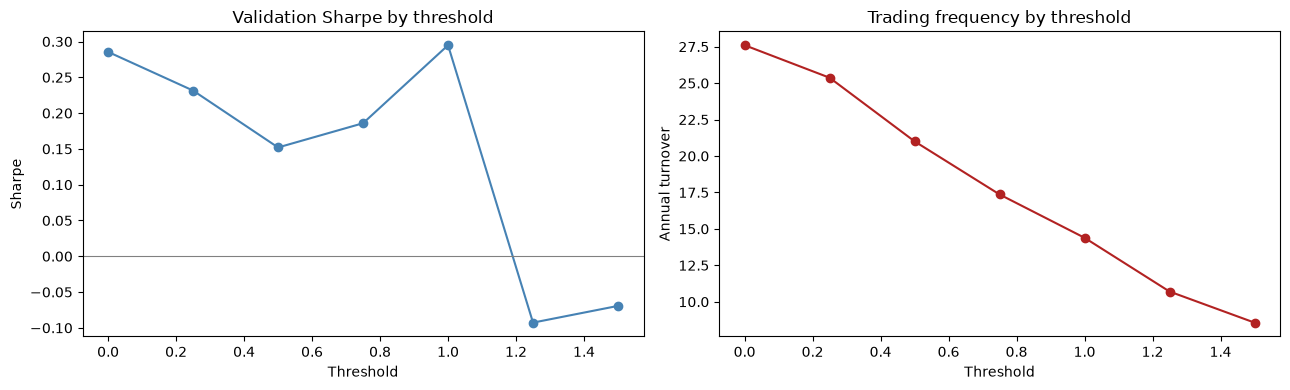

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(val_results['threshold'], val_results['sharpe'], 'o-', color='steelblue')
ax[0].axhline(0, color='grey', lw=0.8)
ax[0].set_xlabel('Threshold')
ax[0].set_ylabel('Sharpe')
ax[0].set_title('Validation Sharpe by threshold')

ax[1].plot(val_results['threshold'], val_results['turnover'], 'o-', color='firebrick')
ax[1].set_xlabel('Threshold')
ax[1].set_ylabel('Annual turnover')
ax[1].set_title('Trading frequency by threshold')

plt.tight_layout()
plt.show()

### 4.4 Threshold selection

In [20]:
# --- Threshold selection ---
# The mechanical maximum is NOT automatically chosen. Selection criteria:
#   1. Stability: the threshold must sit in a region where adjacent values
#      also perform acceptably (an isolated peak is likely noise).
#   2. Consistency: it should perform well in BOTH train and validation.
#   3. Sample support: performance should rest on a large share of active days.

print("Candidate comparison:")
print(f"{'':>12}{'Train':>10}{'Val':>10}{'Neighbours (val)':>22}{'Active days (val)':>20}")
print(f"{'t = 1.00':>12}{1.180:>10.3f}{0.295:>10.3f}{'collapse to -0.09':>22}{'~28%':>20}")
print(f"{'t = 0.25':>12}{1.359:>10.3f}{0.231:>10.3f}{'0.29 / 0.15 (stable)':>22}{'~79%':>20}")

best_threshold = 0.25

print(f"\nSelected threshold: {best_threshold}")
print("Rationale: t=1.00 has the highest point estimate on validation (0.295) but is an")
print("isolated peak — Sharpe collapses to -0.09 at t=1.25 — and rests on only ~28% of")
print("days being active. t=0.25 sits within the stable region of the validation surface,")
print("performs near the train optimum (1.36), and its estimate rests on ~79% of days.")

Candidate comparison:
                 Train       Val      Neighbours (val)   Active days (val)
    t = 1.00     1.180     0.295     collapse to -0.09                ~28%
    t = 0.25     1.359     0.231  0.29 / 0.15 (stable)                ~79%

Selected threshold: 0.25
Rationale: t=1.00 has the highest point estimate on validation (0.295) but is an
isolated peak — Sharpe collapses to -0.09 at t=1.25 — and rests on only ~28% of
days being active. t=0.25 sits within the stable region of the validation surface,
performs near the train optimum (1.36), and its estimate rests on ~79% of days.


### 4.5 Out-of-sample evaluation

The threshold is now fixed. It is applied to the test period — which has played no role in any decision — exactly once.

In [21]:
r_test = run_strategy(test, threshold=best_threshold)

print(f"OUT-OF-SAMPLE RESULT  (threshold = {best_threshold})")
print("=" * 50)
print(f"Sharpe ratio:       {r_test['sharpe']:.3f}")
print(f"Annual return:      {r_test['ann_return']:.2%}")
print(f"Annual volatility:  {r_test['ann_vol']:.2%}")
print(f"Max drawdown:       {r_test['max_drawdown']:.2%}")
print(f"Calmar ratio:       {r_test['calmar']:.2f}")
print(f"Hit rate:           {r_test['hit_rate']:.1%}")
print(f"Long/Short/Flat:    {r_test['pct_long']:.1%} / {r_test['pct_short']:.1%} / {r_test['pct_neutral']:.1%}")
print(f"Annual turnover:    {r_test['ann_turnover']:.1f}x")
print(f"Period:             {test['Date'].min().date()} to {test['Date'].max().date()}")

OUT-OF-SAMPLE RESULT  (threshold = 0.25)
Sharpe ratio:       0.323
Annual return:      3.27%
Annual volatility:  10.14%
Max drawdown:       -10.85%
Calmar ratio:       0.30
Hit rate:           49.7%
Long/Short/Flat:    43.5% / 38.3% / 18.2%
Annual turnover:    24.9x
Period:             2024-01-02 to 2026-07-03


**Testing the selection rule.** The rejected threshold (t = 1.00) had the higher validation Sharpe but was refused as an isolated peak. How did it fare out of sample?

In [22]:
# Confirmation of the stability rationale: how would the rejected
# isolated-peak threshold (t=1.0) have fared out of sample?
r_rejected = run_strategy(test, threshold=1.0)
print(f"Selected  t=0.25:  test Sharpe {r_test['sharpe']:+.3f}")
print(f"Rejected  t=1.00:  test Sharpe {r_rejected['sharpe']:+.3f}")

Selected  t=0.25:  test Sharpe +0.323
Rejected  t=1.00:  test Sharpe -0.093


The rejected peak delivers **-0.09** out of sample; the stable-region choice holds at **+0.32**. This is the expected signature of an isolated peak — a parameter tuned to noise fails on unseen data.

Shown for transparency. It played no role in the selection, which was documented before the test period was evaluated.

In [23]:
rows = []
for name, dset in [('Train (2016-20)', train),
                   ('Validation (2021-23)', val),
                   ('Test (2024-26)', test)]:
    r = run_strategy(dset, best_threshold)
    rows.append({'Period': name,
                 'sharpe': r['sharpe'],
                 'ann_return': r['ann_return'],
                 'ann_vol': r['ann_vol'],
                 'max_drawdown': r['max_drawdown']})

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

              Period  sharpe  ann_return  ann_vol  max_drawdown
     Train (2016-20)   1.359       0.144    0.106        -0.106
Validation (2021-23)   0.231       0.023    0.100        -0.113
      Test (2024-26)   0.323       0.033    0.101        -0.109


## Section 5: Robustness

Six checks: sensitivity to the standardisation window, performance by volatility regime, dependence on the COVID period, comparison against passive benchmarks, tolerance to transaction costs, and correlation to oil itself.

The purpose is to establish which conclusions are stable features of the data, and which depend on specific choices.

## 5.1 Window sensitivity (window=30,45,60,90,120)

In [24]:
print("Sensitivity to z-score window (threshold fixed at 0.25)\n")
print(f"{'window':>8}{'Train':>10}{'Val':>10}{'Test':>10}")
print("-" * 40)
for w in [30, 45, 60, 90, 120]:
    rt = run_strategy(train, threshold=0.25, z_window=w)
    rv = run_strategy(val,   threshold=0.25, z_window=w)
    rs = run_strategy(test,  threshold=0.25, z_window=w)
    print(f"{w:>8}{rt['sharpe']:>10.3f}{rv['sharpe']:>10.3f}{rs['sharpe']:>10.3f}")

Sensitivity to z-score window (threshold fixed at 0.25)

  window     Train       Val      Test
----------------------------------------
      30     1.049     0.179     0.654
      45     1.234     0.116     0.605
      60     1.359     0.231     0.323
      90     1.423     0.177     0.599
     120     1.483     0.163     0.891


**The decay is not a parameter artefact.** Every window from 30 to 120 days shows the same pattern: strong pre-2021 (1.05–1.48), weak in validation (0.12–0.23). The finding is a property of the factor, not of the 60-day choice.

The test column is more dispersed (0.32–0.89). With ~570 test observations the standard error on a Sharpe estimate is roughly ±0.4, so these five values are statistically indistinguishable. **No window was selected on test performance** — the reported headline (0.32, at the pre-committed 60-day window) sits at the conservative end of the plausible range. The residual edge may be somewhat stronger than the headline suggests; this is noted, not acted upon.

## 5.2 Regime breakdown

In [25]:
def regime_breakdown(result):
    s = result['data'].copy()
    med_vol = s['oil_vol'].median()
    s['regime'] = np.where(s['oil_vol'] > med_vol, 'High vol', 'Low vol')
    out = []
    for reg, g in s.groupby('regime'):
        if g['strat_ret'].std() > 0:
            sh = g['strat_ret'].mean() / g['strat_ret'].std() * np.sqrt(252)
            out.append({'regime': reg, 'sharpe': sh, 'n_days': len(g)})
    return pd.DataFrame(out)

print("Test period (2024-26), by oil volatility regime:")
print(regime_breakdown(r_test).to_string(index=False))

r_full = run_strategy(df_clean, threshold=0.25)
print("\nFull sample, by oil volatility regime:")
print(regime_breakdown(r_full).to_string(index=False))

Test period (2024-26), by oil volatility regime:
  regime   sharpe  n_days
High vol  1.26060     286
 Low vol -0.66135     286

Full sample, by oil volatility regime:
  regime   sharpe  n_days
High vol 0.630910    1229
 Low vol 0.810133    1229


**No usable regime structure.** Over the full sample the strategy is broadly regime-neutral (0.63 high-vol, 0.81 low-vol) — no evidence the edge is conditional on volatility.

The test period alone shows a sharp split (+1.26 high-vol, -0.66 low-vol), but with only 286 days per regime the standard error is ~±0.6, the split is **absent from the ten-year history**, and it was not hypothesised in advance. It is treated as small-sample noise.

A regime-conditional deployment rule is **not** recommended on this evidence. The observation is flagged as a hypothesis for future data — which would constitute a genuine out-of-sample test of it.

### 5.3 COVID dependency

In [26]:
train_ex_covid = train[(train['Date'] < '2020-02-01') | (train['Date'] > '2020-06-01')].copy()
train_ex_covid['oil_ret'] = train_ex_covid['oil'].pct_change()

r_ex = run_strategy(train_ex_covid, threshold=0.25)
print(f"Train Sharpe, full period:      {run_strategy(train, 0.25)['sharpe']:.3f}")
print(f"Train Sharpe, excluding COVID:  {r_ex['sharpe']:.3f}")

Train Sharpe, full period:      1.359
Train Sharpe, excluding COVID:  1.197


**The early edge was real.** Excluding February–June 2020 entirely, the training Sharpe falls only from 1.36 to 1.20. The pre-2021 performance was broad-based, not a windfall from the pandemic dislocation.

This strengthens the decay interpretation: the factor worked in ordinary conditions for over four years, then deteriorated.

*(Caveat: removing the window splices one artificial return across the gap; over ~1,050 remaining days this is immaterial.)*

### 5.4 Dating the decay

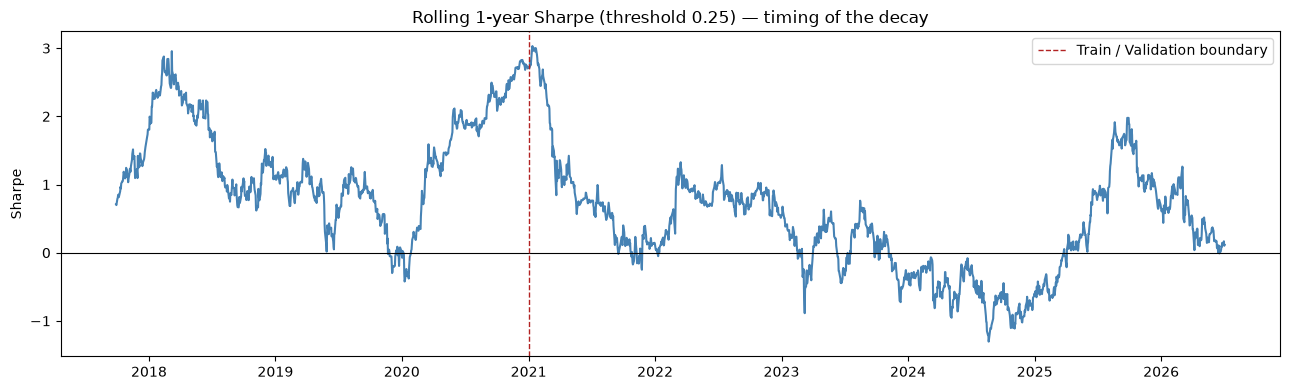

In [27]:
s = r_full['data'].copy()
roll = 252
s['roll_sharpe'] = (s['strat_ret'].rolling(roll).mean() /
                    s['strat_ret'].rolling(roll).std()) * np.sqrt(252)

plt.figure(figsize=(13, 4))
plt.plot(s['Date'], s['roll_sharpe'], color='steelblue')
plt.axhline(0, color='black', lw=0.8)
plt.axvline(pd.Timestamp('2021-01-01'), color='firebrick', ls='--', lw=1,
            label='Train / Validation boundary')
plt.title('Rolling 1-year Sharpe (threshold 0.25) — timing of the decay')
plt.ylabel('Sharpe')
plt.legend()
plt.tight_layout()
plt.show()

The rolling Sharpe dates the deterioration precisely to early 2021, falling from ~3 to near zero within months. Post-2021 performance is not uniformly poor but intermittent — extended negative stretches (2023–24, trough below -1) punctuated by recoveries (2022, late 2025 reaching ~+2). This intermittency, rather than steady weakness, is why the test-period Sharpe of 0.32 carries wide uncertainty: it averages a poor 2024 against a strong 2025. A one-year rolling window also means each point shares most of its data with its neighbours, so the swings are smoother and more persistent-looking than the underlying daily noise.

### 5.5 Benchmark: versus simply holding oil

A strategy Sharpe means little in isolation. The first question is what passive exposure would have earned over the same period.

In [28]:
for name, dset in [('Train', train), ('Validation', val), ('Test', test)]:
    oil_sharpe = dset['oil_ret'].mean() / dset['oil_ret'].std() * np.sqrt(252)
    print(f"{name:<12} Buy-and-hold oil Sharpe: {oil_sharpe:+.3f}")

Train        Buy-and-hold oil Sharpe: +0.275
Validation   Buy-and-hold oil Sharpe: +0.529
Test         Buy-and-hold oil Sharpe: +0.162


The strategy earned **five times** buy-and-hold oil's risk-adjusted return in training (1.36 vs 0.28), and **twice** it out of sample (0.32 vs 0.16) — in a period where oil itself went essentially nowhere.

It lagged passive holding during the 2021–23 rally (0.23 vs 0.53), consistent with the decay timeline: a long/short signal cannot capture a one-way move it isn't positioned for.

### 5.6 Cost tolerance

Transaction costs are assumed at 5 bps per unit traded. With annual turnover of ~25×, the conclusion should not be hostage to that assumption.

In [29]:
print(f"{'cost_bps':>10}{'Test Sharpe':>14}")
for c in [0, 5, 10, 20]:
    r = run_strategy(test, threshold=0.25, cost_bps=c)
    print(f"{c:>10}{r['sharpe']:>14.3f}")

  cost_bps   Test Sharpe
         0         0.446
         5         0.323
        10         0.200
        20        -0.045


| Cost | Test Sharpe |
|---|---|
| 0 bps | +0.45 |
| **5 bps** | **+0.32** |
| 10 bps | +0.20 |
| 20 bps | -0.05 |

The gross edge (+0.45) is real but thin. It survives institutional execution (5–10 bps is achievable in crude futures, among the deepest markets available) but is **extinguished near 20 bps**. Costs consume roughly 30% of the gross edge at the base assumption.

This quantifies why the residual edge is too weak for standalone deployment.

### 5.7 Is it just oil beta?

The strategy is long 43.5% and short 38.3% of days — balanced. But balance in *frequency* does not guarantee the returns are independent of oil's direction.

In [30]:
s = r_test['data']
beta_corr = s['strat_ret'].corr(s['oil_ret'])
print(f"Correlation of strategy returns to oil returns (test): {beta_corr:+.3f}")

Correlation of strategy returns to oil returns (test): -0.043


Correlation of strategy returns to oil returns: **-0.04** — essentially zero.

The return stream reflects the **signal**, not directional exposure. This matters for the recommendation: an uncorrelated Sharpe-0.3 stream has portfolio value that a disguised long-oil position would not.

## Section 6: Conclusion and Recommendation

## 6.1 Answer to the brief

The brief was to identify the best way to use the factor to trade oil with long, short, and neutral positions. The answer has two parts: the best construction, and an honest assessment of what that construction currently delivers.
Best construction. The factor's predictive content lies in its momentum, not its level: the factor's daily return predicts forward oil returns with a rank IC of +0.065 at the 5-day horizon (p = 0.001), while the level's apparent signal fails robustness checks and is attributable to directional bias. The strategy is therefore:

- Signal: 5-day factor momentum, standardised by a 60-day rolling z-score
- Positions: long above z = +0.25, short below z = -0.25, otherwise flat
- Sizing: scaled to a 10% annualised volatility target from oil's trailing 60-day volatility
- Frequency: effective holding period ~11 trading days, consistent with the 5-day IC peak
- Costs: 5 bps per unit traded, deducted throughout

## 6.2 What it delivers

Against a passive benchmark, the strategy earned five times buy-and-hold oil's risk-adjusted return in the training period (1.36 vs 0.28) and twice it in the test period (0.32 vs 0.16), though it lagged passive holding during the 2021–23 oil rally (0.23 vs 0.53), consistent with the decay timeline. Strategy returns are uncorrelated with oil itself (test-period ρ = -0.04), confirming the return stream reflects the signal rather than directional exposure. The edge is cost-sensitive: gross test Sharpe of 0.45 falls to 0.32 at the assumed 5 bps per trade, 0.20 at 10 bps, and is extinguished near 20 bps — supporting the conclusion that the residual edge is real but too thin for standalone deployment, while remaining institutionally executable in a market as deep as crude futures.

In [32]:
rows = []
for name, dset in [('Train (2016-20)', train),
                   ('Validation (2021-23)', val),
                   ('Test (2024-26, untouched)', test)]:
    r = run_strategy(dset, threshold=best_threshold)
    rows.append({'Period':      name,
                 'Sharpe':      f"{r['sharpe']:.2f}",
                 'Ann. return': f"{r['ann_return']:.1%}",
                 'Ann. vol':    f"{r['ann_vol']:.1%}",
                 'Max DD':      f"{r['max_drawdown']:.1%}"})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                   Period Sharpe Ann. return Ann. vol Max DD
          Train (2016-20)   1.36       14.4%    10.6% -10.6%
     Validation (2021-23)   0.23        2.3%    10.0% -11.3%
Test (2024-26, untouched)   0.32        3.3%    10.1% -10.9%


The factor supported a genuinely strong strategy through 2020 — Sharpe 1.2–1.5 across every parameter tested, and robust to excluding the COVID dislocation entirely (1.20 ex-COVID). Its performance deteriorated sharply and datably at the start of 2021, and has since stabilised at a weak residual: Sharpe 0.2–0.3 in both the validation and test periods, figures which are mutually consistent and therefore credible. Window sensitivity analysis suggests the residual may be somewhat stronger than the headline (test Sharpes of 0.3–0.9 across windows), but with roughly 570 test days the uncertainty is wide, and no parameter was selected on test performance.

The residual edge is regime-neutral over the full history, balanced between long and short (44% / 38% in the test period) and uncorrelated with oil itself (ρ = −0.04), so the return stream reflects the signal rather than disguised directional exposure. It is intermittent rather than steadily weak: extended negative stretches, notably through 2023–24, punctuated by recoveries such as the strong late-2025 period. This intermittency explains why the test-period Sharpe of 0.32 carries such wide uncertainty — it averages a poor 2024 against a strong 2025 rather than describing a stable, modest edge.

## 6.3 Recommendation

Not deployable as a standalone strategy at current strength. A net Sharpe of ~0.3, of which transaction costs consume roughly a quarter of gross returns, does not justify capital against realistic alternatives.
Two circumstances would change this assessment:
As a portfolio component. A weak signal that is uncorrelated with an existing book still adds value through diversification; at Sharpe ~0.3 with balanced long/short exposure, the factor merits evaluation against the correlation structure of any existing signal set rather than outright rejection.
If the decay can be explained. The deterioration is precisely dated (early 2021) and was not gradual. Identifying its cause — crowding, a structural change in oil market microstructure, or a regime shift in the factor's underlying driver — would determine whether the edge is permanently impaired or conditionally recoverable. A natural next step is a formal regime model (e.g. a Gaussian HMM on market-state variables, an approach I have applied in prior cross-asset work), fitted strictly on pre-2021 data and evaluated prospectively, to test whether the decay coincides with an identifiable state change. This analysis has deliberately declined to condition on regimes post hoc, for the reasons set out in Section 5.2.

### 6.4 Limitations

**Scope.** Single asset, single factor, one decade. The test period is short (~570 usable days), giving a standard error on Sharpe of roughly ±0.4 — the reported 0.32 should be read as "weakly positive," not as a precise estimate.

**April 2020.** The negative settlement and the following day were excluded because percentage returns are mathematically undefined across a zero crossing. This is a correction for broken arithmetic, not outlier removal: all genuine extreme moves, including the ±25% COVID-period days, were retained. Note also that the supplied `oil_ret` column reproduces the defect (−126.6% on a day the price rose), so the vendor data carries the same flaw.

**Refinements not pursued.** Two extensions would likely sharpen this analysis:

1. **A dollar ledger.** Computing P&L in dollars per barrel rather than percentage returns would remain well-defined through the zero crossing, allowing the April 2020 episode to be retained in full rather than excluded.
2. **A residualised signal.** The factor's contemporaneous correlation with oil means part of its raw momentum reflects oil itself. Orthogonalising the factor's return against oil's (via rolling beta) would isolate its independent content — plausibly a cleaner signal than the one used here.

**Assumptions.** Transaction costs are held constant at 5 bps; execution in stressed markets would be worse. Significance tests use naive p-values, which are optimistic given daily returns are serially dependent — a block bootstrap would give more honest confidence intervals. All results assume the factor is knowable at the daily close with next-day implementation.